## Import

In [58]:
import numpy as np
import pandas as pd # type: ignore
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from rbf_main import RBF, one_hot, set_seed

## Separation du dataset

In [59]:
#np.random.seed(4)
NB_IMG_PER_CLASSES = 2000

base = Path("data")
classes = ["compost", "dechets_chimiques", "recyclable"]

rows = []
for cls in classes:
    images = sorted((base / cls).glob("*.jpg"))[:NB_IMG_PER_CLASSES]
    for img_path in images:
        rows.append({
            "path": str(img_path),
            "nom_image": img_path.name,
            "classe": cls
        })

df = pd.DataFrame(rows)

def assign_split(n, ratios=(0.70, 0.15, 0.15)):
    labels = np.array(["train"] * n)
    idx = np.random.permutation(n)
    t1 = int(n * ratios[0])
    t2 = int(n * (ratios[0] + ratios[1]))
    labels[idx[t1:t2]] = "val"
    labels[idx[t2:]] = "test"
    return labels

df["cat"] = df.groupby("classe")["path"] \
              .transform(lambda x: assign_split(len(x)))

print(f"Total : {len(df)} images")
print(df.groupby("classe")["cat"].value_counts())
df.head()

Total : 6000 images
classe             cat  
compost            train    1400
                   test      300
                   val       300
dechets_chimiques  train    1400
                   val       300
                   test      300
recyclable         train    1400
                   val       300
                   test      300
Name: count, dtype: int64


,path,nom_image,classe,cat
0,data/compost/compost_0001.jpg,compost_0001.jpg,compost,train
1,data/compost/compost_0002.jpg,compost_0002.jpg,compost,train
2,data/compost/compost_0003.jpg,compost_0003.jpg,compost,test
3,data/compost/compost_0004.jpg,compost_0004.jpg,compost,train
4,data/compost/compost_0005.jpg,compost_0005.jpg,compost,train


## Transformation des données (redimension + gray lvl)

In [60]:
IMG = 16
IMG_SIZE = (IMG, IMG)

def load_image(path):
    try:
        img = Image.open(path).convert("L")
        img = img.resize(IMG_SIZE)
        return np.array(img, dtype=np.float32).flatten() / 255.0
    except (OSError, IOError):
        return None

df["pixels"] = [load_image(p) for p in tqdm(df["path"], desc="Chargement")]

n_before = len(df)
df = df.dropna(subset=["pixels"]).reset_index(drop=True)
print(f"Images corrompues supprimées : {n_before - len(df)}")

X_train = np.stack(df[df["cat"] == "train"]["pixels"].values)
X_val   = np.stack(df[df["cat"] == "val"]["pixels"].values)
X_test  = np.stack(df[df["cat"] == "test"]["pixels"].values)

label_map = {cls: i for i, cls in enumerate(classes)}
y_train = df[df["cat"] == "train"]["classe"].map(label_map).values
y_val   = df[df["cat"] == "val"]["classe"].map(label_map).values
y_test  = df[df["cat"] == "test"]["classe"].map(label_map).values

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Labels:  {label_map}")

Chargement: 100%|██████████| 6000/6000 [01:26<00:00, 69.56it/s] 

Images corrompues supprimées : 1
X_train: (4199, 256)  y_train: (4199,)
X_val:   (900, 256)    y_val:   (900,)
X_test:  (900, 256)   y_test:  (900,)
Labels:  {'compost': 0, 'dechets_chimiques': 1, 'recyclable': 2}


## Entrainement

  0%|          | 1/1000 [00:00<03:38,  4.58it/s]

epoch 0: train=0.320610  val=0.310832  acc=0.4444


 10%|█         | 102/1000 [00:19<02:47,  5.37it/s]

epoch 100: train=0.262650  val=0.269670  acc=0.4844


 20%|██        | 202/1000 [00:38<02:30,  5.32it/s]

...

 80%|████████  | 802/1000 [02:31<00:37,  5.34it/s]

epoch 800: train=0.253692  val=0.266925  acc=0.4800


 90%|█████████ | 902/1000 [02:50<00:19,  5.01it/s]

epoch 900: train=0.253374  val=0.266989  acc=0.4811


100%|██████████| 1000/1000 [03:10<00:00,  5.25it/s]


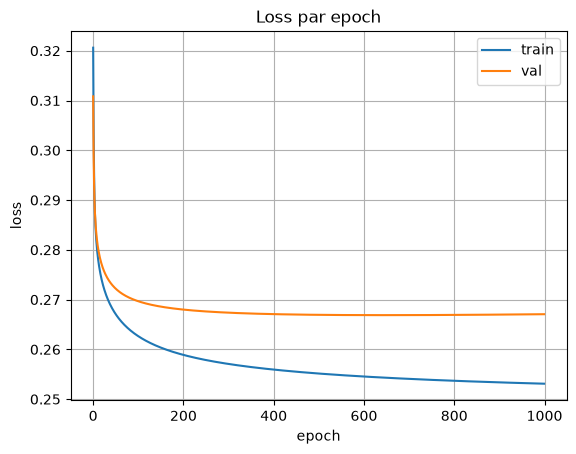

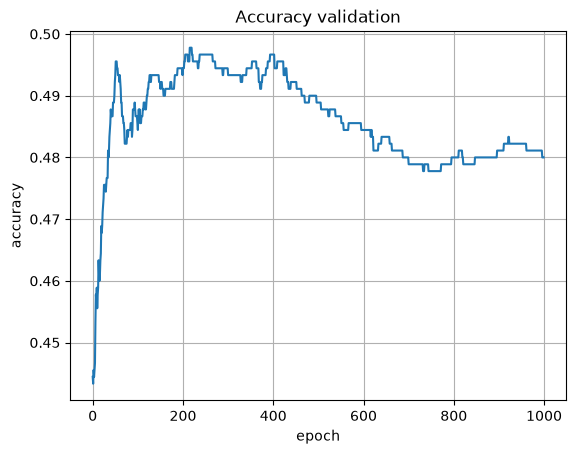

In [61]:
model = RBF(nb_centres=100, gamma=.5)
model.init_classif(X_train, 3)

Y_train_oh = one_hot(y_train, 3)
Y_val_oh   = one_hot(y_val, 3)

train_losses, val_losses, accs = [], [], []

for epoch in tqdm(range(1000)):
    train_losses.append(model.train_epoch(Y_train_oh, learning_rate=.01))

    scores_val = model.predict_scores(X_val)
    val_losses.append(np.mean((scores_val - Y_val_oh) ** 2))

    accs.append(np.mean(model.predict(X_val) == y_val))

    if epoch % 100 == 0:
        print(f"epoch {epoch}: train={train_losses[-1]:.6f}  val={val_losses[-1]:.6f}  acc={accs[-1]:.4f}")

# courbes
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(True)
plt.title("Loss par epoch"); plt.show(); plt.clf()

plt.plot(accs)
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.title("Accuracy validation"); plt.grid(True); plt.show()